# Part I - Ford GoBike System Data Exploration
### by Vikash Kushwaha

## Introduction

### Dataset Overview

The Ford GoBike System Data contains information about individual bike-sharing trips made during February 2019 in the San Francisco Bay Area. Each trip record includes ride duration, start and end timestamps, station information, geographic coordinates, user type, gender, birth year, and bike-sharing participation status.

The objective of this exploratory analysis is to understand travel behavior, identify patterns in ride duration, investigate how user demographics influence bike usage, and discover temporal and spatial trends within the bike-sharing system.

Throughout this analysis, visualizations are used to examine the distributions of individual variables and relationships among multiple variables to uncover meaningful insights about the usage of the Ford GoBike service.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Configure plot appearance
sns.set_style("whitegrid")

In [65]:
# Reusable plotting functions

def add_title_and_labels(title, xlabel, ylabel):
    """
    Add a title and axis labels to plots.
    """
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


def finalize_plot():
    """
    Apply common formatting to plots.
    """
    plt.tight_layout()
    plt.show()
    
def display_distribution_stats(data, distribution_name):
    """
    Display summary statistics to assess skewness.
    """
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]

    print(f"\n{distribution_name}")
    print(f"Mean   : {mean:.2f}")
    print(f"Median : {median:.2f}")
    print(f"Mode   : {mode:.2f}")
    print(f"Skewness : {data.skew():.3f}")
    
def add_distribution_statistics(data):
    """
    Plot Mean, Median, and Mode as vertical lines on a histogram.
    """
    mean = data.mean()
    median = data.median()
    mode = data.mode()[0]

    plt.axvline(mean, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean:.1f}')

    plt.axvline(median, color='green', linestyle='--', linewidth=2,
                label=f'Median: {median:.1f}')

    plt.axvline(mode, color='orange', linestyle='--', linewidth=2,
                label=f'Mode: {mode:.1f}')

    plt.legend()

## Preliminary Wrangling

This section loads the dataset, examines its structure, checks data quality, and performs initial preprocessing before beginning the exploratory analysis.

In [3]:
# Load the dataset

df = pd.read_csv("201902-fordgobike-tripdata.csv")

# Display the first few records
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [4]:
# Display dataset dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (183412, 16)


In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [6]:
# Display summary statistics

df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [7]:
# Display summary statistics for categorical variables

df.describe(include='object')

,start_time,end_time,start_station_name,end_station_name,user_type,member_gender,bike_share_for_all_trip
count,183412,183412,183215,183215,183412,175147,183412
unique,183401,183397,329,329,2,3,2
top,2019-02-25 08:52:07.5820,2019-02-11 08:03:22.6020,Market St at 10th St,San Francisco Caltrain Station 2 (Townsend St...,Subscriber,Male,No
freq,2,2,3904,4857,163544,130651,166053


In [8]:
# Check missing values

df.isnull().sum().sort_values(ascending=False)

member_birth_year          8265
member_gender              8265
start_station_id            197
start_station_name          197
end_station_id              197
end_station_name            197
duration_sec                  0
start_time                    0
end_time                      0
start_station_latitude        0
start_station_longitude       0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
bike_share_for_all_trip       0
dtype: int64

In [9]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Data Cleaning

Before performing exploratory analysis, several preprocessing steps are required:

- Convert datetime columns into datetime format.
- Create additional time-based features.
- Calculate rider age using the birth year.
- Remove unrealistic age values.
- Convert selected columns into categorical data types.

These steps improve the quality of the analysis and make temporal investigations easier.

In [10]:
# Convert datetime columns

df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [11]:
# Create useful date and time features

df['start_hour'] = df['start_time'].dt.hour
df['start_day'] = df['start_time'].dt.day_name()
df['start_month'] = df['start_time'].dt.month_name()

# Calculate rider age

df['age'] = 2019 - df['member_birth_year']

In [12]:
# Remove unrealistic age values

df = df[(df['age'] >= 18) & (df['age'] <= 80)]

In [13]:
# Convert selected columns to categorical type

categorical_columns = [
    'user_type',
    'member_gender',
    'bike_share_for_all_trip',
    'start_day',
    'start_month'
]

for column in categorical_columns:
    df[column] = df[column].astype('category')

In [14]:
# Verify cleaned dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174955 entries, 0 to 183411
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174955 non-null  int64         
 1   start_time               174955 non-null  datetime64[ns]
 2   end_time                 174955 non-null  datetime64[ns]
 3   start_station_id         174760 non-null  float64       
 4   start_station_name       174760 non-null  object        
 5   start_station_latitude   174955 non-null  float64       
 6   start_station_longitude  174955 non-null  float64       
 7   end_station_id           174760 non-null  float64       
 8   end_station_name         174760 non-null  object        
 9   end_station_latitude     174955 non-null  float64       
 10  end_station_longitude    174955 non-null  float64       
 11  bike_id                  174955 non-null  int64         
 12  user_type            

## What is the structure of your dataset?

The dataset contains over **180,000 bike-sharing trips** recorded during February 2019. Each observation represents a single bike trip and includes information related to trip duration, station locations, timestamps, rider demographics, and membership type.

The dataset contains a mixture of:

- Numerical variables (trip duration, latitude, longitude, birth year)
- Categorical variables (user type, gender, bike-share participation)
- Datetime variables (start time and end time)

Additional variables such as **age**, **start hour**, **day of week**, and **month** were created during preprocessing to facilitate temporal analysis.

## What is/are the main feature(s) of interest in your dataset?

The primary feature of interest is **trip duration**, as it reflects how riders utilize the bike-sharing system.

This analysis also investigates how trip duration varies with:

- User Type
- Gender
- Age
- Time of Day
- Day of Week

These variables provide insights into rider behavior and commuting patterns.

## What features in the dataset do you think will help support your investigation into your feature(s) of interest?

Several variables are expected to explain variations in trip duration and rider behavior:

- **duration_sec** — measures the length of each trip.
- **user_type** — distinguishes Subscribers from Customers.
- **member_gender** — compares riding behavior across genders.
- **age** — evaluates whether rider age influences trip duration.
- **start_hour** — identifies peak riding hours.
- **start_day** — compares weekday and weekend usage.
- **bike_share_for_all_trip** — examines whether participation in the bike-share program influences trip characteristics.

These variables collectively provide demographic and temporal perspectives on bike-sharing usage.

## Univariate Exploration

In this section, individual variables are explored to understand their distributions and identify any unusual patterns or outliers. These findings will guide the subsequent bivariate and multivariate analyses.

Each investigation follows the **Question–Visualization–Observation** framework.

## Question 1
### How is trip duration distributed among all bike trips?

Trip duration is the primary variable of interest. Understanding its distribution provides insight into how long riders typically use the bike-sharing service.


Original Trip Duration Distribution
Mean   : 704.52
Median : 511.00
Mode   : 272.00
Skewness : 28.465


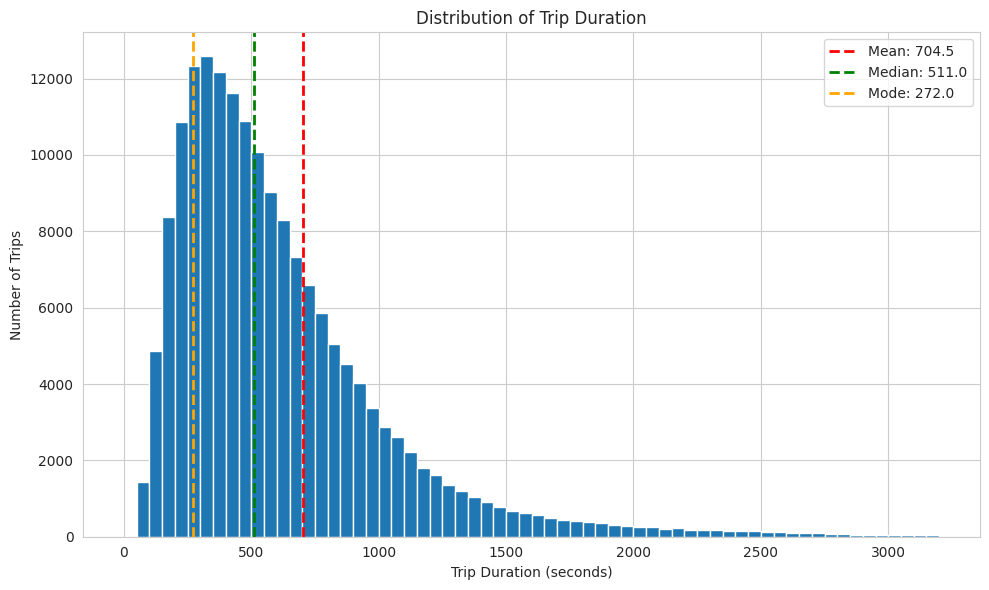

In [66]:
# Distribution of trip duration

plt.figure(figsize=(10,6))

bins = np.arange(0, df['duration_sec'].quantile(0.99) + 50, 50)

plt.hist(df['duration_sec'], bins=bins)

add_distribution_statistics(df['duration_sec'])

plt.legend()

add_title_and_labels('Distribution of Trip Duration','Trip Duration (seconds)','Number of Trips')

display_distribution_stats(
    df['duration_sec'],
    "Original Trip Duration Distribution"
)

finalize_plot()

### Observation

- The distribution of trip duration is highly right-skewed.
- Most bike trips last less than 20 minutes.
- A small number of trips have exceptionally long durations, indicating potential outliers.
- The skewness suggests that a logarithmic transformation may provide a clearer visualization in future analyses.

## Question 2
### What is the distribution of trip duration after applying a logarithmic transformation?

Since the trip duration distribution is heavily skewed, applying a logarithmic transformation helps reveal its underlying shape.


Log-Transformed Trip Duration Distribution
Mean   : 2.71
Median : 2.71
Mode   : 2.43
Skewness : 0.454


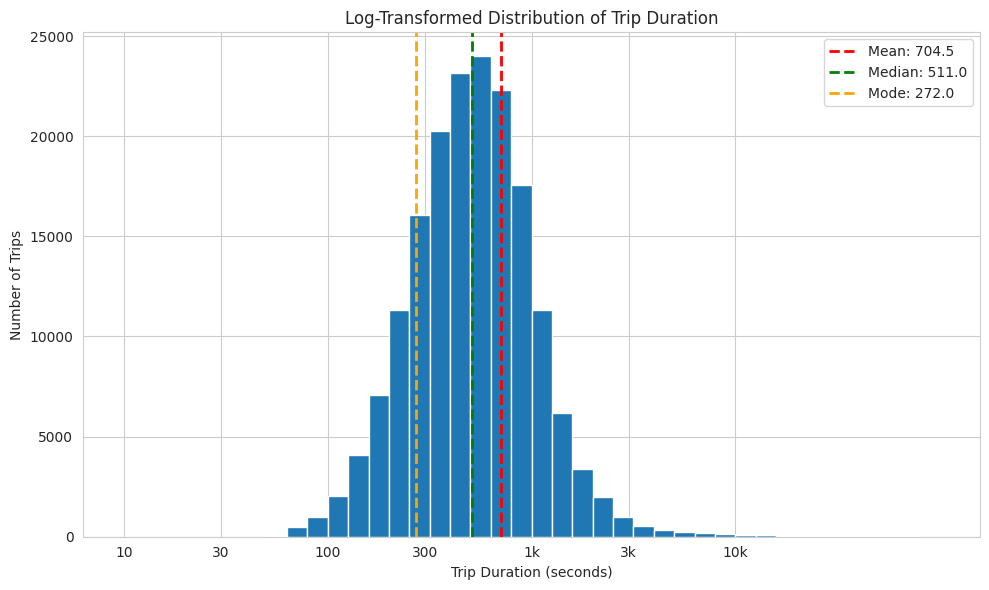

In [68]:
# Log-transformed trip duration
df['log_duration'] = np.log10(df['duration_sec'])

display_distribution_stats(
    df['log_duration'],
    "Log-Transformed Trip Duration Distribution"
)

plt.figure(figsize=(10,6))

bins = 10 ** np.arange(1,5.1,0.1)

plt.hist(df['duration_sec'], bins=bins)

plt.xscale('log')

add_distribution_statistics(df['duration_sec'])

ticks = [10,30,100,300,1000,3000,10000]
labels = ['10','30','100','300','1k','3k','10k']

plt.xticks(ticks, labels)

add_title_and_labels('Log-Transformed Distribution of Trip Duration','Trip Duration (seconds)','Number of Trips')

finalize_plot()

### Observation

- The log-transformed distribution appears approximately unimodal.
- Most trips fall between 5 and 20 minutes.
- The transformation makes the distribution easier to interpret by reducing the impact of extreme values.
- After applying the logarithmic transformation, the skewness is substantially reduced. The mean and median become much closer together, and the skewness value moves closer to zero, indicating a more symmetric distribution. This makes the transformed distribution more suitable for comparison and further analysis.

## Question 3
### Which user type uses the bike-sharing system most frequently?

The dataset distinguishes between Subscribers and Customers. Comparing their frequencies provides insight into the composition of the user base.

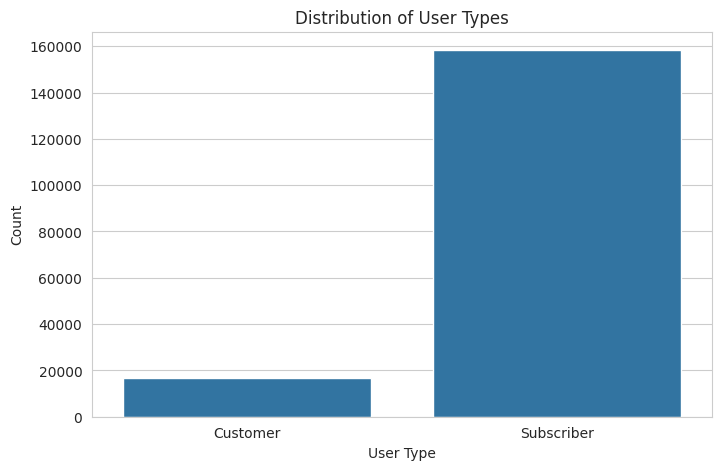

In [17]:
plt.figure(figsize=(8,5))

base_color = sns.color_palette()[0]

sns.countplot(data=df,
              x='user_type',
              color=base_color)

add_title_and_labels('Distribution of User Types','User Type','Count')

plt.show()

### Observation

- Subscribers constitute the overwhelming majority of riders.
- Customers represent only a small proportion of total trips.
- This indicates that the bike-sharing system is primarily used by regular members rather than casual riders.

## Question 4
### What is the gender distribution of riders?

Understanding gender distribution provides demographic insight into the user population.

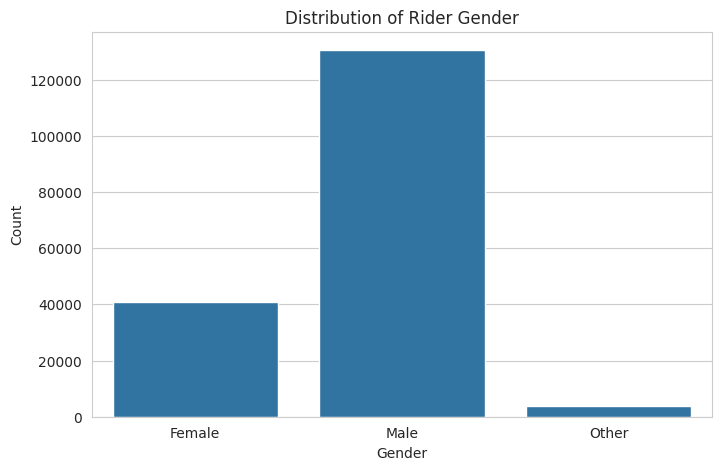

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='member_gender',
              color=base_color)

add_title_and_labels('Distribution of Rider Gender','Gender','Count')

plt.show()

### Observation

- Male riders account for the largest proportion of trips.
- Female riders contribute a smaller share of rides.
- A limited number of records are classified as "Other," indicating a relatively small representation in the dataset.

## Question 5
### What is the age distribution of riders?

Rider age helps identify the primary demographic using the bike-sharing service.

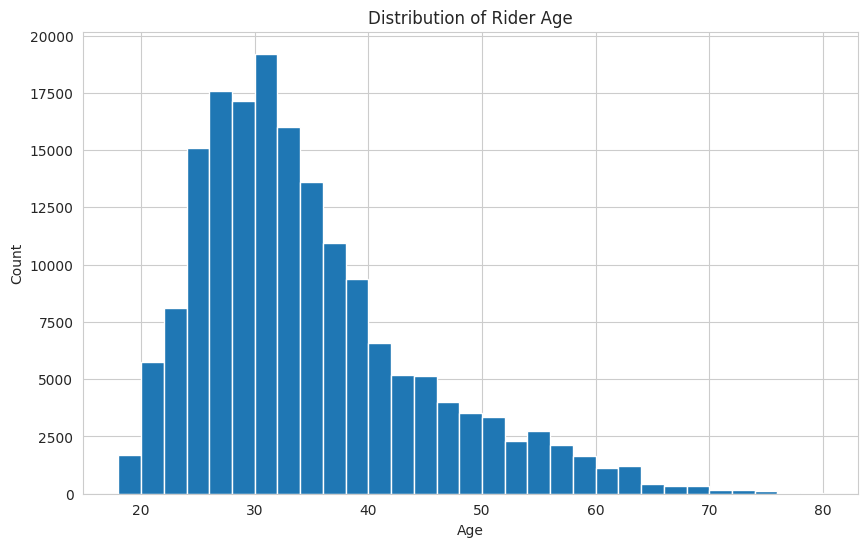

In [52]:
plt.figure(figsize=(10,6))

bins = np.arange(18,81,2)

plt.hist(df['age'],bins=bins)


add_title_and_labels('Distribution of Rider Age','Age','Count')

plt.show()

### Observation

- Most riders are between 25 and 40 years old.
- Very few riders are above 60 years of age.
- The age distribution is moderately right-skewed, suggesting that the bike-sharing service is most popular among young and middle-aged adults.

## Question 6
### During which hours of the day are bike trips most common?

Examining hourly trip counts helps identify commuting and leisure travel patterns.

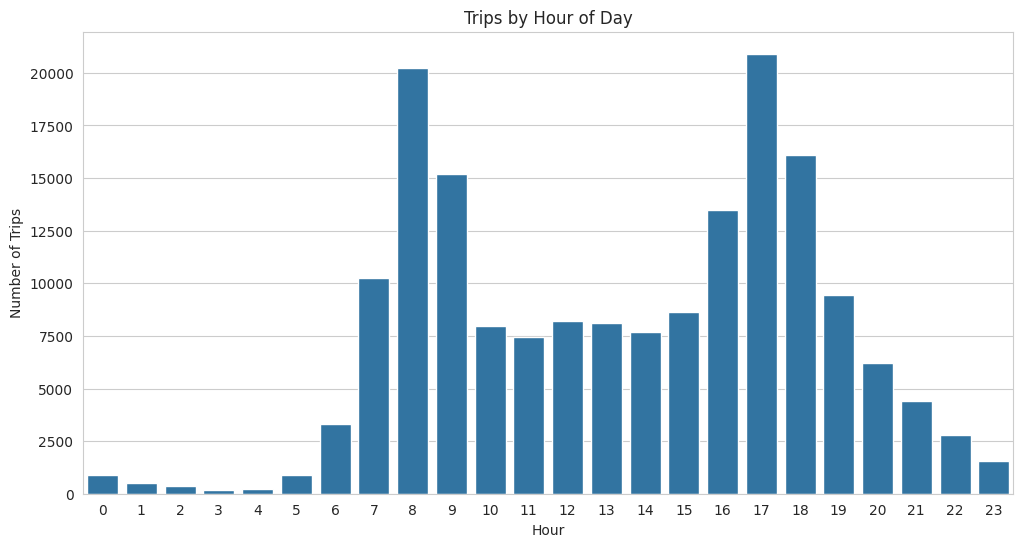

In [30]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x='start_hour',
              color=base_color)

add_title_and_labels('Trips by Hour of Day','Hour','Number of Trips')

plt.show()

### Observation

- Bike usage peaks during morning and evening hours.
- These peaks correspond closely with typical commuting periods.
- Ridership is lowest during late-night and early-morning hours.

## Question 7
### Which day of the week records the highest number of trips?

Investigating weekly trends helps distinguish commuting behavior from recreational riding.

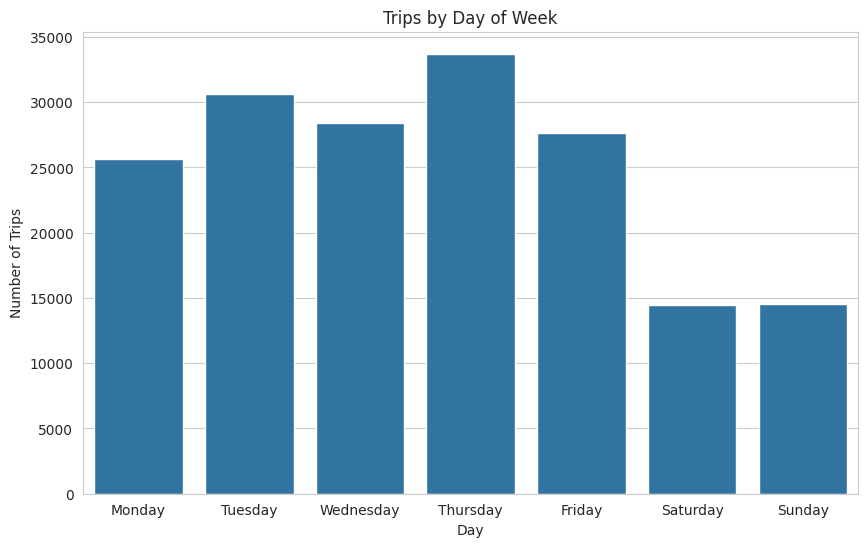

In [31]:
day_order = ['Monday',
             'Tuesday',
             'Wednesday',
             'Thursday',
             'Friday',
             'Saturday',
             'Sunday']

plt.figure(figsize=(10,6))

sns.countplot(data=df,
              x='start_day',
              order=day_order,
              color=base_color)

add_title_and_labels('Trips by Day of Week','Day','Number of Trips')

plt.show()

### Observation

- Weekdays generally record more trips than weekends.
- Tuesday through Thursday show particularly high ridership.
- Weekend usage declines, suggesting that many trips are related to daily commuting.

## Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

The primary variable of interest, **trip duration**, exhibits a highly right-skewed distribution. Most trips last between **5 and 20 minutes**, while a relatively small number of trips have much longer durations, creating several noticeable outliers.

To better understand the distribution, a **logarithmic transformation** was applied to the `duration_sec` variable. The transformed distribution appeared much more symmetric and easier to interpret, making it suitable for subsequent comparisons across user groups.

## Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

Several preprocessing steps were performed before analysis. The `start_time` and `end_time` columns were converted to datetime format, allowing extraction of useful temporal features such as **hour of day**, **day of week**, and **month**.

The `member_birth_year` variable was used to calculate rider age, and records with unrealistic ages (below 18 or above 80 years) were removed to minimize the effect of erroneous data.

Finally, because trip duration was highly skewed, a logarithmic transformation was used in several visualizations to improve readability and interpretation.

# Bivariate Exploration

In this section, relationships between pairs of variables are explored to better understand the factors influencing trip duration and rider behavior. The analysis focuses on how demographic and temporal variables relate to trip duration and each other.

## Question 1
### Does trip duration vary by user type?

Subscribers and Customers may use the bike-sharing service differently. This visualization compares trip duration between the two groups.

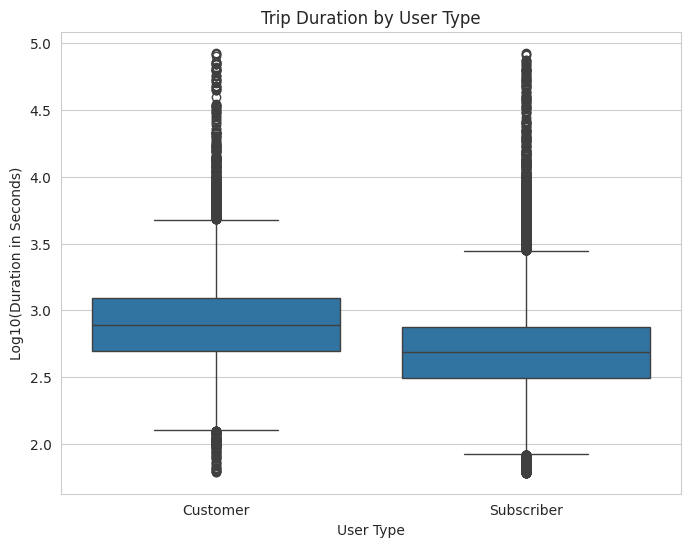

In [62]:
# Log-transform duration for better visualization
df['log_duration'] = np.log10(df['duration_sec'])

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='user_type',
    y='log_duration',
    color=sns.color_palette()[0]
)

add_title_and_labels('Trip Duration by User Type','User Type','Log10(Duration in Seconds)')

plt.show()

### Observation

- Customers generally take longer trips than Subscribers.
- Subscribers have a more concentrated distribution, suggesting more consistent ride durations.
- Several outliers exist for both groups, representing unusually long trips.

## Question 2
### Does trip duration differ across genders?

This analysis compares ride durations among different gender groups.

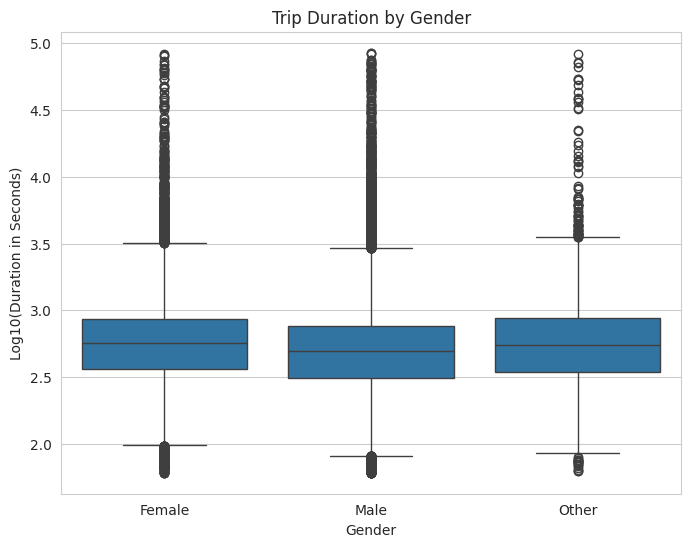

In [33]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='member_gender',
    y='log_duration',
    color=sns.color_palette()[0]
)

add_title_and_labels('Trip Duration by Gender','Gender','Log10(Duration in Seconds)')

plt.show()

### Observation

- Median trip durations are relatively similar across gender groups.
- Male and female riders exhibit comparable riding patterns.
- The "Other" category shows greater variability but contains significantly fewer observations.

## Question 3
### Is there a relationship between rider age and trip duration?

A scatter plot helps determine whether age influences the duration of bike trips.

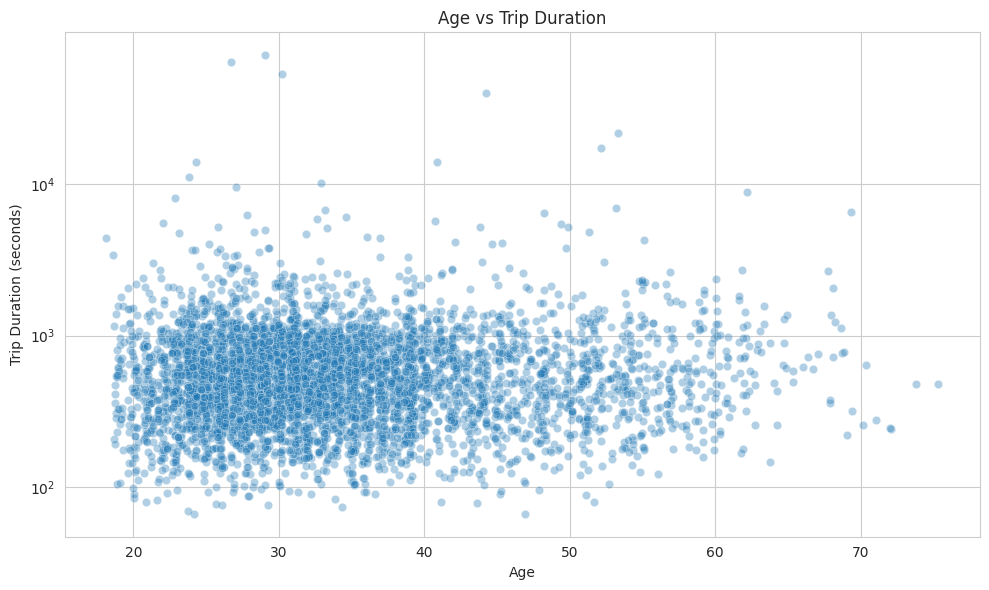

In [46]:
# Sample the data for faster plotting
sample = df.sample(5000, random_state=42).copy()

# Add jitter to reduce overlap
sample['age_jitter'] = sample['age'] + np.random.uniform(-0.4, 0.4, len(sample))

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample,
    x='age_jitter',
    y='duration_sec',
    alpha=0.35
)

plt.yscale('log')

add_title_and_labels("Age vs Trip Duration","Age","Trip Duration (seconds)")

finalize_plot()

### Observation

- Most trips are concentrated among riders aged 25–40 years.
- No strong linear relationship exists between age and trip duration.
- Older riders appear slightly less likely to take very long trips.

## Question 4
### How does user type vary across the days of the week?

This clustered bar chart compares the number of Subscriber and Customer trips throughout the week.

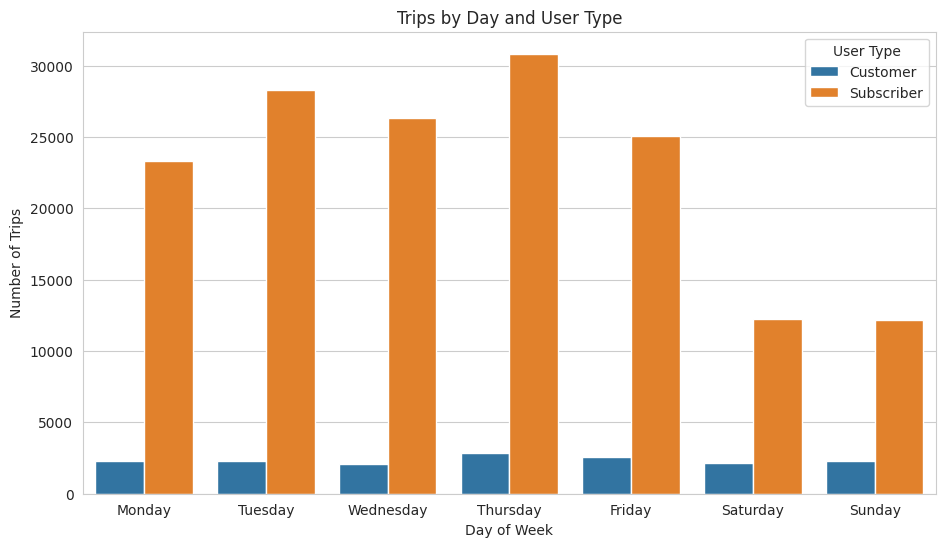

In [35]:
plt.figure(figsize=(11,6))

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

sns.countplot(
    data=df,
    x='start_day',
    hue='user_type',
    order=day_order
)

add_title_and_labels('Trips by Day and User Type','Day of Week','Number of Trips')

plt.legend(title='User Type')

plt.show()

### Observation

- Subscribers dominate trip counts on every day of the week.
- Weekday ridership is substantially higher than weekend ridership.
- Customer usage increases slightly during weekends, suggesting more recreational trips.

## Question 5
### Are the numerical variables correlated?

A correlation heatmap helps identify relationships among numerical variables.

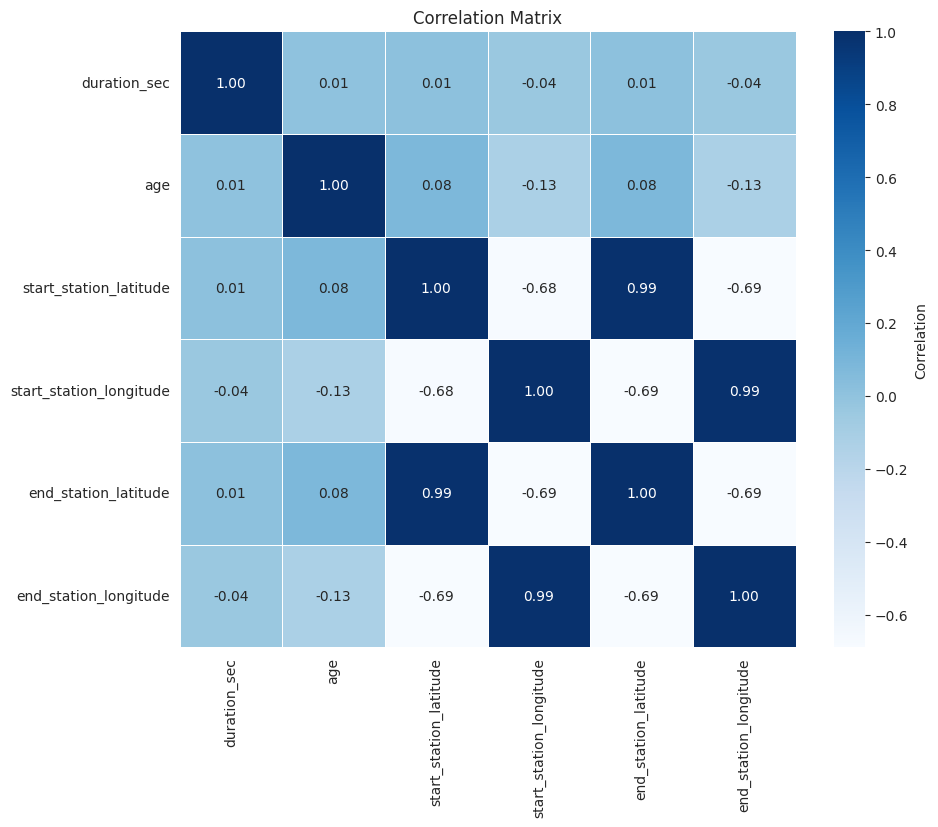

In [53]:
numeric_cols = [
    'duration_sec',
    'age',
    'start_station_latitude',
    'start_station_longitude',
    'end_station_latitude',
    'end_station_longitude'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation'}
)

add_title_and_labels('Correlation Matrix',"","")

plt.show()

### Observation

- Geographic coordinates exhibit strong correlations because nearby start and end stations are often used together.
- Rider age has very little correlation with trip duration.
- No strong correlation exists between trip duration and the remaining numerical variables.

## Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

Trip duration varies considerably across different user groups. Customers generally take longer trips than Subscribers, suggesting that casual riders tend to use the service for leisure, whereas Subscribers primarily use it for commuting. Rider age exhibits only a weak relationship with trip duration, and gender shows relatively little influence on ride length.

Temporal analysis also indicates that Subscribers dominate weekday usage, while Customers contribute relatively more trips during weekends.

## Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

The strongest relationship among the remaining variables is between the geographic coordinates of start and end stations, which is expected because many trips occur between nearby stations. Additionally, weekday ridership is substantially higher than weekend ridership, reinforcing the observation that the bike-sharing system is widely used for daily commuting.

# Multivariate Exploration

In this section, three or more variables are analyzed simultaneously to uncover more complex relationships within the dataset. Building on the previous analyses, the focus is on understanding how demographic and temporal variables interact to influence trip duration and riding behavior.

## Question 1
### How does trip duration vary by user type across different genders?

This FacetGrid compares the distribution of trip duration for Subscribers and Customers while separating riders by gender.

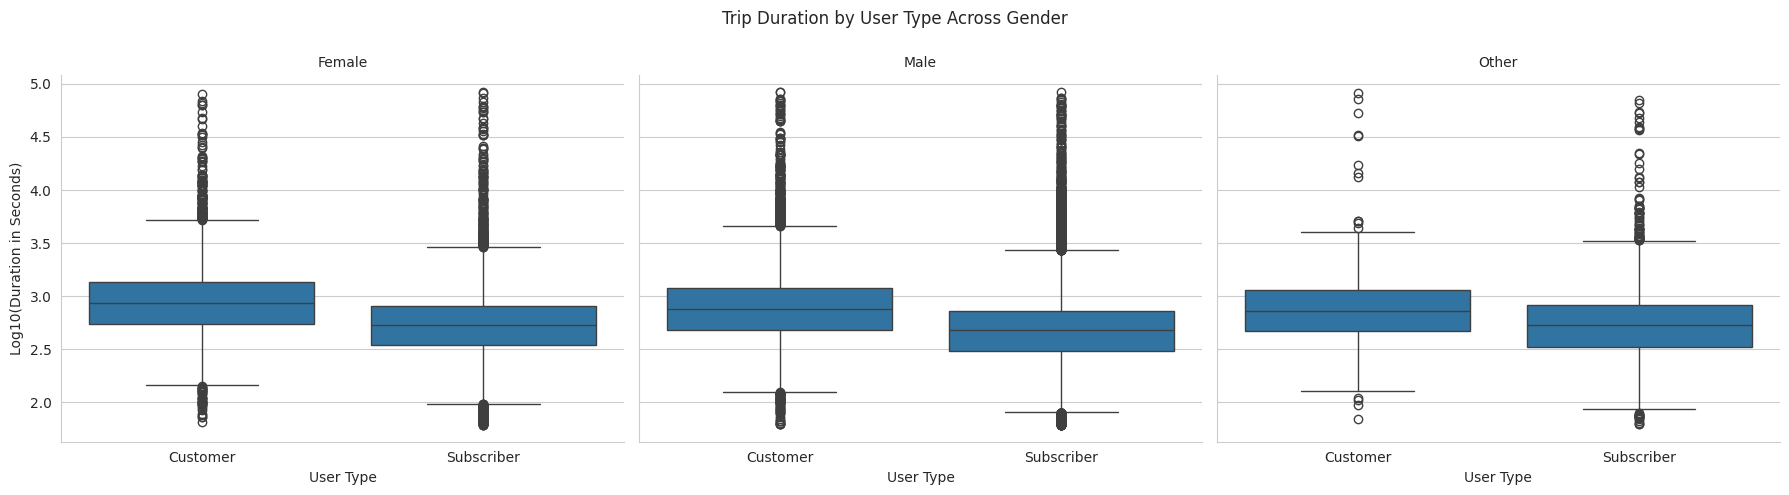

In [27]:
g = sns.FacetGrid(
    data=df,
    col='member_gender',
    height=5,
    aspect=1.2
)

g.map_dataframe(
    sns.boxplot,
    x='user_type',
    y='log_duration',
    color=sns.color_palette()[0]
)

g.set_axis_labels("User Type", "Log10(Duration in Seconds)")
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Trip Duration by User Type Across Gender")

plt.show()

### Observation

- Across all gender groups, Customers tend to take longer trips than Subscribers.
- Male and female riders display similar ride-duration distributions.
- The "Other" category contains fewer observations, leading to greater variability in the distribution.
- User type has a stronger influence on trip duration than gender.

## Question 2
### Does rider age influence trip duration differently for Subscribers and Customers?

This scatter plot examines the relationship between rider age and trip duration while distinguishing user types using color.

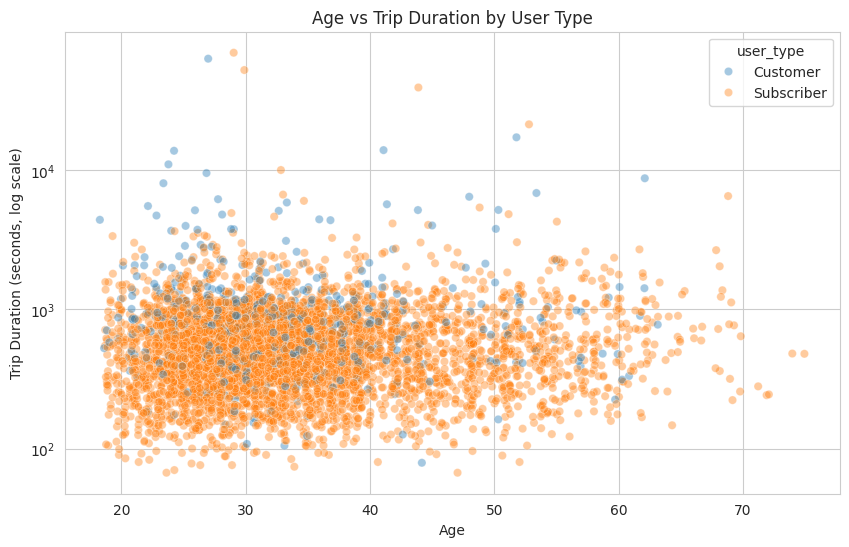

In [47]:
plt.figure(figsize=(10,6))

sample = df.sample(5000, random_state=42).copy()

sample['age_jitter'] = sample['age'] + np.random.uniform(-0.4,0.4,len(sample))

sns.scatterplot(
    data=sample,
    x='age_jitter',
    y='duration_sec',
    hue='user_type',
    alpha=0.4
)

plt.yscale('log')

add_title_and_labels('Age vs Trip Duration by User Type','Age','Trip Duration (seconds, log scale)')

plt.show()

### Observation

- Subscribers make up the majority of observations across all age groups.
- Customers generally exhibit longer ride durations than Subscribers.
- There is no strong relationship between age and trip duration.
- Most riders are concentrated between 25 and 40 years of age.

## Question 3
### How does average trip duration vary by day of the week for different user types?

This visualization compares average ride duration across weekdays for Subscribers and Customers.

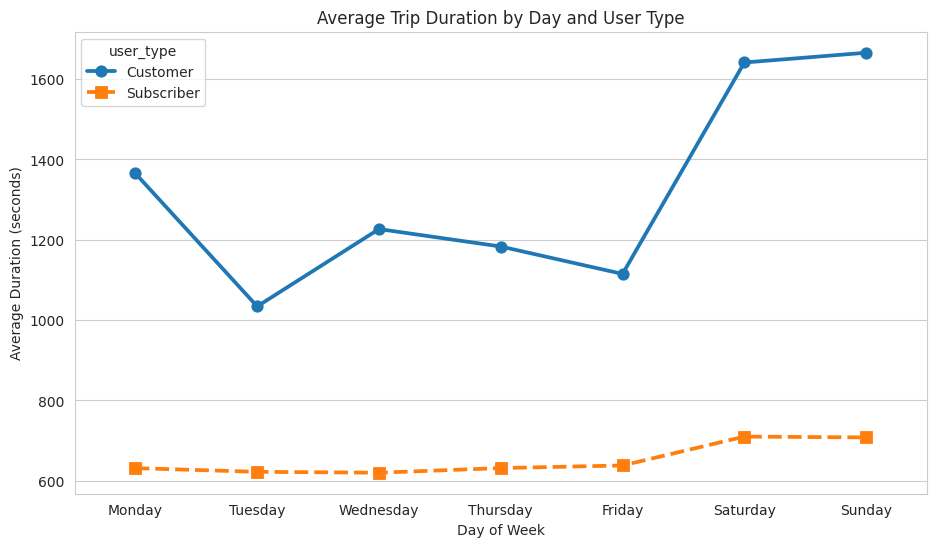

In [54]:
plt.figure(figsize=(11,6))

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

sns.pointplot(
    data=df,
    x='start_day',
    y='duration_sec',
    hue='user_type',
    order=day_order,
    errorbar=None,
    markers=['o','s'],
    linestyles=['-','--']
)

add_title_and_labels('Average Trip Duration by Day and User Type','Day of Week','Average Duration (seconds)')

plt.show()

### Observation

- Customers consistently have longer average ride durations than Subscribers.
- Subscriber trip durations remain relatively stable throughout the week.
- Customer ride durations increase slightly during weekends, suggesting greater recreational usage.

## Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

The multivariate analysis confirmed that **user type** is the strongest factor associated with trip duration. Customers consistently took longer trips than Subscribers regardless of gender or rider age. This pattern remained consistent across all visualizations, indicating that membership status has a greater influence on ride duration than demographic characteristics.

Combining user type with temporal variables further strengthened this observation. Subscribers maintained relatively consistent trip durations throughout the week, whereas Customers tended to take longer trips during weekends, suggesting more recreational riding behavior.

## Were there any interesting or surprising interactions between features?

One interesting finding is that gender has relatively little influence on trip duration once user type is considered. Similarly, rider age shows only a weak relationship with ride length despite covering a broad range of ages.

The analysis consistently demonstrates that user type is the most influential variable, while temporal patterns indicate that Subscribers mainly use the bike-sharing system for weekday commuting and Customers use it more frequently for longer recreational trips, particularly during weekends.

# Conclusions

## Summary of Findings

The exploratory analysis of the Ford GoBike dataset revealed several important insights regarding rider behavior and trip characteristics.

### Key Findings

- Most bike trips last between **5 and 20 minutes**, with the trip duration distribution showing a strong right skew.
- **Subscribers** account for the majority of trips, indicating that the system is primarily used by regular commuters.
- **Customers** generally take longer rides than Subscribers, suggesting more recreational use.
- Bike usage peaks during **morning and evening commuting hours**, particularly on weekdays.
- Riders are predominantly **25 to 40 years old**, with relatively few older riders.
- Male riders make up the largest proportion of users.
- Rider age shows only a weak relationship with trip duration.
- User type is the strongest predictor of ride duration among the variables explored.

## Reflection

The analysis successfully identified temporal, demographic, and behavioral patterns within the Ford GoBike system. Feature engineering and data cleaning improved the quality of the exploration, while univariate, bivariate, and multivariate visualizations provided a comprehensive understanding of rider behavior.

Overall, the results indicate that the bike-sharing system is primarily used for weekday commuting by Subscribers, while Customers tend to use the service for longer and more recreational trips.